In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, classification_report

In [ ]:
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

os.makedirs("plots", exist_ok=True)
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

CLASSES = ["airplane", "automobile", "bird", "cat", "deer","dog", "frog", "horse", "ship", "truck"]

def save(name):
    plt.savefig("plots/" + name, dpi=600, bbox_inches="tight")
    plt.show()

In [ ]:
print("\n--- Task 1: Load CIFAR-10 ---")

transform = transforms.ToTensor()
train_set = datasets.CIFAR10("./data", train=True, download=True, transform=transform)
test_set = datasets.CIFAR10("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)

print("Training images:", len(train_set))
print("Testing images :", len(test_set))
print("Image shape    :", tuple(train_set[0][0].shape), "(C, H, W)")
print("Classes        :", len(CLASSES))


--- Task 1: Load CIFAR-10 ---


100%|██████████| 170M/170M [25:01<00:00, 114kB/s] 


Training images: 50000
Testing images : 10000
Image shape    : (3, 32, 32) (C, H, W)
Classes        : 10


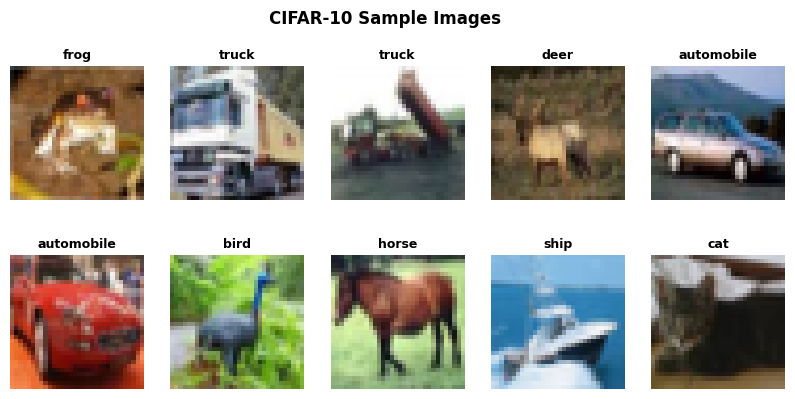

In [ ]:
# Plot 1: Sample Images
plt.figure(figsize=(10, 4.5))
for i in range(10):
    img, label = train_set[i]
    plt.subplot(2, 5, i + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(CLASSES[label], fontsize=9)
    plt.axis("off")
plt.suptitle("CIFAR-10 Sample Images", fontweight="bold")
save("01_sample_images.png")

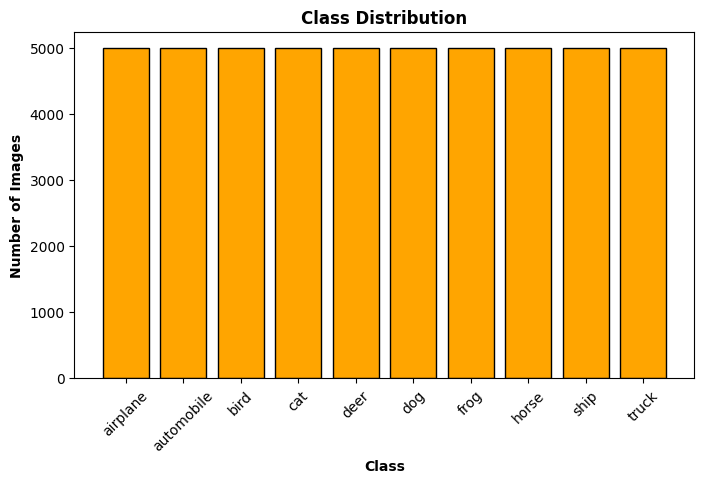

Class counts   : [5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000]


In [ ]:
counts = np.bincount(np.array(train_set.targets))
plt.figure(figsize=(8, 4.5))
plt.bar(CLASSES, counts, color="orange", edgecolor="black")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.xticks(rotation=45)
save("02_class_distribution.png")
print("Class counts   :", counts.tolist())

In [ ]:
print("\n--- Task 2: Kernel size comparison ---")

sample = next(iter(train_loader))[0][:8].to(device)

for k in (3, 5, 7):
    conv = nn.Conv2d(3, 16, kernel_size=k).to(device)
    with torch.no_grad():
        out = conv(sample)
    formula = (32 - k) + 1
    print(f"Kernel {k}x{k}: formula = {formula}x{formula}, "
          f"actual = {tuple(out.shape[1:])}")


--- Task 2: Kernel size comparison ---
Kernel 3x3: formula = 30x30, actual = (16, 30, 30)
Kernel 5x5: formula = 28x28, actual = (16, 28, 28)
Kernel 7x7: formula = 26x26, actual = (16, 26, 26)


In [ ]:
print("\n--- Task 3: Stride and padding ---")

for pad_name, p in (("valid", 0), ("same", 1)):
    for s in (1, 2):
        conv = nn.Conv2d(3, 16, kernel_size=3, stride=s, padding=p).to(device)
        with torch.no_grad():
            out = conv(sample)
        formula = (32 - 3 + 2 * p) // s + 1
        print(f"padding={pad_name} (P={p}), stride={s}: "
              f"formula = {formula}x{formula}, actual = {tuple(out.shape[1:])}")


--- Task 3: Stride and padding ---
padding=valid (P=0), stride=1: formula = 30x30, actual = (16, 30, 30)
padding=valid (P=0), stride=2: formula = 15x15, actual = (16, 15, 15)
padding=same (P=1), stride=1: formula = 32x32, actual = (16, 32, 32)
padding=same (P=1), stride=2: formula = 16x16, actual = (16, 16, 16)


In [ ]:
print("\n--- Task 6: CNN model ---")


class CNN(nn.Module):
    def __init__(self, pool="max"):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        Pool = nn.MaxPool2d if pool == "max" else nn.AvgPool2d
        self.pool = Pool(2, 2)
        self.fc = nn.Linear(32 * 8 * 8, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        return self.fc(x)          # softmax is applied inside CrossEntropyLoss


def train(model, epochs=20):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    hist = {"train_acc": [], "train_loss": [], "val_acc": [], "val_loss": []}

    for ep in range(epochs):
        model.train()
        loss_sum = correct = total = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        hist["train_loss"].append(loss_sum / total)
        hist["train_acc"].append(correct / total)

        model.eval()
        loss_sum = correct = total = 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss_sum += criterion(out, y).item() * y.size(0)
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)
        hist["val_loss"].append(loss_sum / total)
        hist["val_acc"].append(correct / total)

        print(f"Epoch {ep+1}/{epochs} - loss {hist['train_loss'][-1]:.4f} "
              f"acc {hist['train_acc'][-1]*100:.2f}% - "
              f"val_loss {hist['val_loss'][-1]:.4f} "
              f"val_acc {hist['val_acc'][-1]*100:.2f}%")
    return hist


model = CNN("max")
params = sum(p.numel() for p in model.parameters())
print(model)
print("Trainable parameters:", params)

hist = train(model)


--- Task 6: CNN model ---
CNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=2048, out_features=10, bias=True)
)
Trainable parameters: 25578
Epoch 1/20 - loss 1.5106 acc 46.30% - val_loss 1.3253 val_acc 51.58%
Epoch 2/20 - loss 1.1889 acc 58.44% - val_loss 1.1455 val_acc 59.17%
Epoch 3/20 - loss 1.0605 acc 63.10% - val_loss 1.0435 val_acc 63.72%
Epoch 4/20 - loss 0.9842 acc 65.91% - val_loss 0.9984 val_acc 64.89%
Epoch 5/20 - loss 0.9268 acc 67.85% - val_loss 0.9851 val_acc 66.00%
Epoch 6/20 - loss 0.8871 acc 69.29% - val_loss 0.9526 val_acc 66.32%
Epoch 7/20 - loss 0.8544 acc 70.29% - val_loss 0.9472 val_acc 67.05%
Epoch 8/20 - loss 0.8312 acc 71.46% - val_loss 0.9450 val_acc 67.04%
Epoch 9/20 - loss 0.8062 acc 72.08% - val_loss 0.9185 val_acc 68.32%
Epoch 10/20 - loss

In [ ]:
print("\n--- Task 4: Feature maps ---")

img = test_set[7][0].unsqueeze(0).to(device)
with torch.no_grad():
    fmaps = F.relu(model.conv1(img))[0].cpu()
print("conv1 output shape:", tuple(fmaps.shape))

In [ ]:
plt.figure(figsize=(10, 5))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(fmaps[i], cmap="viridis")
    plt.title(f"Map {i+1}", fontsize=9)
    plt.axis("off")
plt.suptitle("Feature Maps After First Convolution Layer", fontweight="bold")
save("07_feature_maps.png")

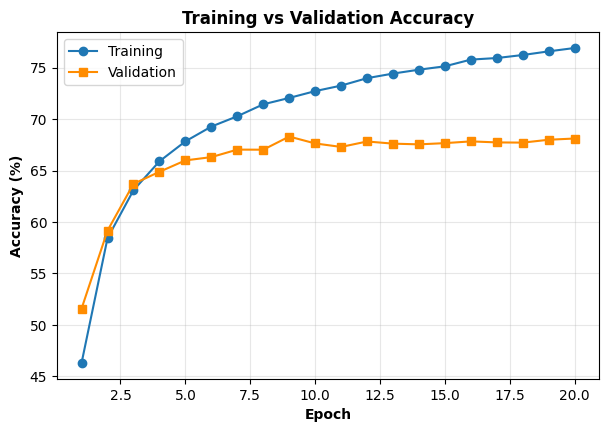

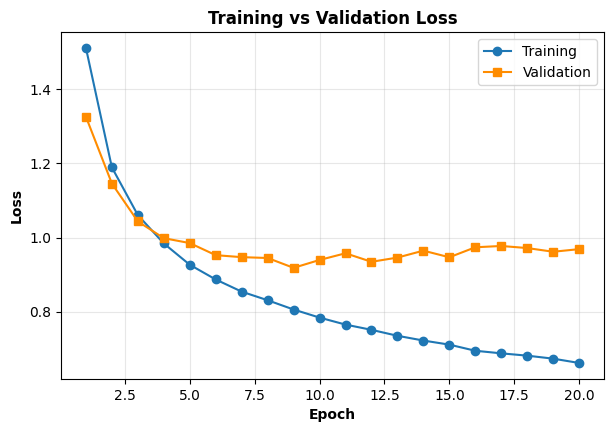

In [ ]:
epochs = range(1, len(hist["train_acc"]) + 1)

plt.figure(figsize=(7, 4.5))
plt.plot(epochs, [a * 100 for a in hist["train_acc"]], "o-", label="Training")
plt.plot(epochs, [a * 100 for a in hist["val_acc"]], "s-", color="darkorange", label="Validation")
plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy"); plt.grid(alpha=0.3); plt.legend()
save("03_accuracy.png")

plt.figure(figsize=(7, 4.5))
plt.plot(epochs, hist["train_loss"], "o-", label="Training")
plt.plot(epochs, hist["val_loss"], "s-", color="darkorange", label="Validation")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training vs Validation Loss"); plt.grid(alpha=0.3); plt.legend()
save("04_loss.png")

In [ ]:
print("\n--- Task 7: Evaluation ---")

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(device))
        y_pred.append(out.argmax(1).cpu())
        y_true.append(y)
y_true = torch.cat(y_true).numpy()
y_pred = torch.cat(y_pred).numpy()

test_acc = (y_true == y_pred).mean()
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro")
cm = confusion_matrix(y_true, y_pred)

print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))


--- Task 7: Evaluation ---
              precision    recall  f1-score   support

    airplane     0.5890    0.8270    0.6880      1000
  automobile     0.7868    0.7970    0.7919      1000
        bird     0.5396    0.5720    0.5553      1000
         cat     0.4980    0.4880    0.4929      1000
        deer     0.6818    0.5720    0.6221      1000
         dog     0.6051    0.5930    0.5990      1000
        frog     0.7394    0.7690    0.7539      1000
       horse     0.7954    0.6960    0.7424      1000
        ship     0.8501    0.6920    0.7630      1000
       truck     0.7819    0.7780    0.7799      1000

    accuracy                         0.6784     10000
   macro avg     0.6867    0.6784    0.6788     10000
weighted avg     0.6867    0.6784    0.6788     10000



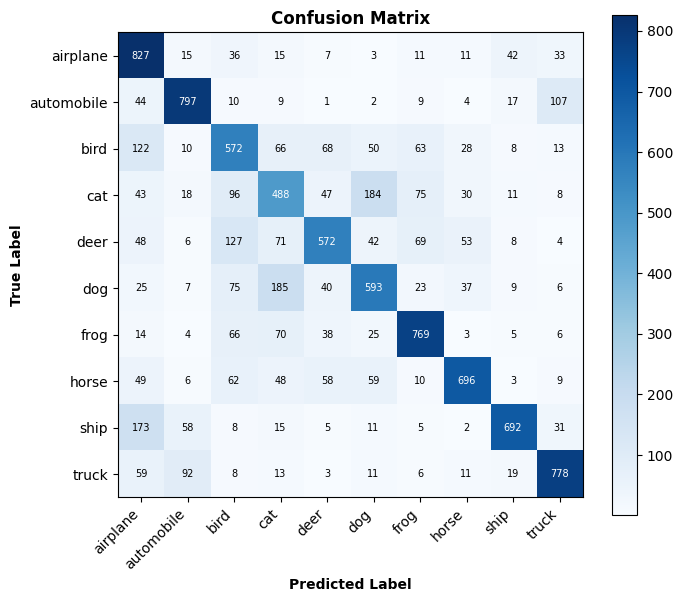

In [ ]:
# Plot 8: Confusion Matrix
plt.figure(figsize=(7.5, 6.5))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(10), CLASSES, rotation=45, ha="right")
plt.yticks(range(10), CLASSES)
plt.xlabel("Predicted Label"); plt.ylabel("True Label")
plt.title("Confusion Matrix")
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
save("08_confusion_matrix.png")

In [ ]:
print("\n--- Task 5: Max pooling vs Average pooling ---")

model_avg = CNN("avg")
hist_avg = train(model_avg)

model_avg.eval()
correct = total = 0
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        correct += (model_avg(x).argmax(1) == y).sum().item()
        total += y.size(0)
avg_acc = correct / total

print("Output size after each pooling layer is the same: 32x32 -> 16x16 -> 8x8")
print(f"Max pooling     test accuracy: {test_acc*100:.2f}%")
print(f"Average pooling test accuracy: {avg_acc*100:.2f}%")


--- Task 5: Max pooling vs Average pooling ---
Epoch 1/20 - loss 1.5843 acc 43.59% - val_loss 1.4019 val_acc 50.89%
Epoch 2/20 - loss 1.3163 acc 53.67% - val_loss 1.2716 val_acc 54.85%
Epoch 3/20 - loss 1.2192 acc 57.29% - val_loss 1.2191 val_acc 56.55%
Epoch 4/20 - loss 1.1423 acc 59.89% - val_loss 1.1504 val_acc 60.03%
Epoch 5/20 - loss 1.0805 acc 62.26% - val_loss 1.1067 val_acc 59.97%
Epoch 6/20 - loss 1.0288 acc 64.19% - val_loss 1.0463 val_acc 63.02%
Epoch 7/20 - loss 0.9897 acc 65.58% - val_loss 1.0308 val_acc 63.71%
Epoch 8/20 - loss 0.9575 acc 66.65% - val_loss 1.0073 val_acc 64.70%
Epoch 9/20 - loss 0.9300 acc 67.83% - val_loss 0.9980 val_acc 65.14%
Epoch 10/20 - loss 0.9055 acc 68.49% - val_loss 0.9910 val_acc 65.87%
Epoch 11/20 - loss 0.8884 acc 69.09% - val_loss 1.0132 val_acc 65.14%
Epoch 12/20 - loss 0.8657 acc 69.80% - val_loss 0.9902 val_acc 65.67%
Epoch 13/20 - loss 0.8501 acc 70.52% - val_loss 0.9725 val_acc 66.72%
Epoch 14/20 - loss 0.8364 acc 70.80% - val_loss 0.9

In [ ]:
print("\n--- Results ---")
print(f"Training Accuracy   : {hist['train_acc'][-1]*100:.2f}%")
print(f"Testing Accuracy    : {test_acc*100:.2f}%")
print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1-score            : {f1:.4f}")
print(f"Number of Parameters: {params}")


--- Results ---
Training Accuracy   : 76.98%
Testing Accuracy    : 67.84%
Precision           : 0.6867
Recall              : 0.6784
F1-score            : 0.6788
Number of Parameters: 25578


In [ ]:
import shutil
from google.colab import files
shutil.make_archive("plots", "zip", "plots")
files.download("plots.zip")